# Lightweight SNR Gate for Hybrid Attention

This notebook trains a small binary model that predicts the routing region from each IQ signal:

- **Low SNR:** `SNR <= 0 dB` → use differential attention
- **High SNR:** `SNR > 0 dB` → use normal attention

The model does **not** predict modulation class. It only predicts which attention model should be used by the hybrid SNR-aware system.

In [3]:
# CELL 1: Repo setup
import os
import sys
import subprocess
from pathlib import Path

os.environ['KERAS_BACKEND'] = 'tensorflow'

REPO_URL = 'https://github.com/akshlabh/amr-5-class.git'
WORK_DIR = Path('/kaggle/working/amr-5-class')

if (Path.cwd() / 'src').exists():
    WORK_DIR = Path.cwd()
    print('Using current repo:', WORK_DIR)
elif (WORK_DIR / 'src').exists():
    print('Using existing repo:', WORK_DIR)
else:
    print('Repo not found locally. Trying git clone...')
    try:
        subprocess.run(['git', 'clone', REPO_URL, str(WORK_DIR)], check=True)
    except Exception as e:
        raise RuntimeError(
            'Could not clone repo. If Kaggle internet is off, upload the repo as a Kaggle dataset '
            'or copy the repo into /kaggle/working/amr-5-class first.'
        ) from e

os.chdir(WORK_DIR)
if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

print('Working directory:', Path.cwd())

Using current repo: /kaggle/working/amr-5-class
Working directory: /kaggle/working/amr-5-class


In [4]:
# CELL 2: Paths and config
from pathlib import Path

CONFIG = Path('configs/exp_snr_gate.yaml')
OUT_DIR = Path('experiments/snr_gate_lightweight')
WEIGHTS = OUT_DIR / 'checkpoints/best_model.weights.h5'
SCALER = OUT_DIR / 'results/snr_gate_feature_scaler.npz'

# Kaggle dataset path candidates. Edit DATASET_PATH manually if your input folder name is different.
candidates = [
    Path('/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat'),
    Path('/kaggle/input/radioml2016-10a/RML2016.10a_dict.pkl'),
    Path('/kaggle/input/radioml2016-10a/RML2016.10a_dict.dat'),
    Path('data/RML2016.10a_5class.pkl'),
    Path('data/RML2016.10a_dict.pkl'),
    Path('data/RML2016.10a_dict.dat'),
]
DATASET_PATH = next((p for p in candidates if p.exists()), None)
if DATASET_PATH is None:
    raise FileNotFoundError('Dataset not found. Set DATASET_PATH to your RML2016.10a pickle/dat file.')

print('Config :', CONFIG.resolve())
print('Dataset:', DATASET_PATH)
print('Output :', OUT_DIR.resolve())

Config : /kaggle/working/amr-5-class/configs/exp_snr_gate.yaml
Dataset: /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
Output : /kaggle/working/amr-5-class/experiments/snr_gate_lightweight


In [5]:
# CELL 3: Quick feature and model sanity check
import numpy as np
import keras
keras.mixed_precision.set_global_policy('float32')

from src.features.signal_features import extract_snr_gate_features
from src.models.snr_gate import build_snr_gate

np.random.seed(42)
X_fake = np.random.randn(8, 2, 128).astype('float32')
features, names = extract_snr_gate_features(X_fake)
print('Feature shape:', features.shape)
print('Feature count:', len(names))
print('First features:', names[:8])
assert features.shape == (8, 29)
assert len(names) == 29
assert np.isfinite(features).all()

model = build_snr_gate(input_dim=features.shape[1])
print('Model params:', model.count_params())
out = model.predict(features, verbose=0)
assert out.shape == (8, 2)
assert np.allclose(out.sum(axis=1), 1.0, atol=1e-5)
print('Sanity check PASSED')
del model

Feature shape: (8, 29)
Feature count: 29
First features: ['amp_mean', 'amp_std', 'amp_max', 'amp_p10', 'amp_p25', 'amp_p50', 'amp_p75', 'amp_p90']


I0000 00:00:1783189310.154573      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model params: 4678
Sanity check PASSED


I0000 00:00:1783189312.293680     142 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [6]:
# CELL 4: Train SNR gate from scratch
import shutil
import subprocess

FORCE_TRAIN_FROM_SCRATCH = True

if FORCE_TRAIN_FROM_SCRATCH and OUT_DIR.exists():
    print('Removing old SNR-gate output folder:', OUT_DIR)
    shutil.rmtree(OUT_DIR)

cmd = [
    sys.executable,
    'src/train_snr_gate.py',
    '--config', str(CONFIG),
    '--datasetpath', str(DATASET_PATH),
]
print('Running:', ' '.join(cmd))
subprocess.run(cmd, check=True)

assert WEIGHTS.exists(), f'Missing trained weights: {WEIGHTS}'
assert SCALER.exists(), f'Missing scaler: {SCALER}'
print('Training complete.')

Running: /usr/bin/python3 src/train_snr_gate.py --config configs/exp_snr_gate.yaml --datasetpath /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat


I0000 00:00:1783189330.796110     194 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 14979 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


[seed] All seeds fixed to 2016  (Python, NumPy, TensorFlow 2.20.0)
Experiment : snr_gate_lightweight
Task       : binary SNR routing
Rule       : class 0 low <= 0 dB, class 1 high > 0 dB
Dataset    : /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
Classes    : ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
Split      : shuffle_split=False, split_file=None
Checkpoint : experiments/snr_gate_lightweight/checkpoints/best_model.weights.h5
[dataset] Loading 5 classes: ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']
[dataset] SNR range: -20 dB to 18 dB  (20 levels)
[dataset] After normalization — train RMS: 1.0000  (should be ≈1.0)
[dataset] Split: 60000 train | 20000 val | 20000 test samples
Model: "Lightweight_SNR_Gate"


I0000 00:00:1783189335.977543     221 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Training complete.


In [7]:
# CELL 5: Show result tables
import pandas as pd

score = pd.read_csv(OUT_DIR / 'results/test_score.csv')
per_snr = pd.read_csv(OUT_DIR / 'results/snr_gate_acc_per_snr.csv')
conf = pd.read_csv(OUT_DIR / 'results/confusion_normalized.csv')

print('Test score')
display(score)

print('Per-SNR routing accuracy')
display(per_snr)

print('Normalized confusion matrix')
display(conf)

print('Mean low-SNR probability should be high below/at 0 dB and low above 0 dB.')

Test score


,loss,accuracy
0,0.077834,0.9916


Per-SNR routing accuracy


,snr,n_test,accuracy,mean_p_low,mean_p_high,low_route_fraction
0,-20,1000,1.000,0.981286,0.018714,1.000
1,-18,1000,1.000,0.981276,0.018724,1.000
2,-16,1000,1.000,0.981985,0.018015,1.000
3,-14,1000,1.000,0.982580,0.017420,1.000
4,-12,1000,1.000,0.982303,0.017697,1.000
5,-10,1000,1.000,0.981427,0.018573,1.000
6,-8,1000,1.000,0.980455,0.019545,1.000
7,-6,1000,1.000,0.982797,0.017203,1.000
8,-4,1000,1.000,0.984654,0.015346,1.000
9,-2,1000,1.000,0.985817,0.014183,1.000


Normalized confusion matrix


,true/pred,pred_low_snr,pred_high_snr
0,true_low_snr,0.997,0.003
1,true_high_snr,0.015,0.985


Mean low-SNR probability should be high below/at 0 dB and low above 0 dB.


experiments/snr_gate_lightweight/logs/snr_gate_accuracy.png


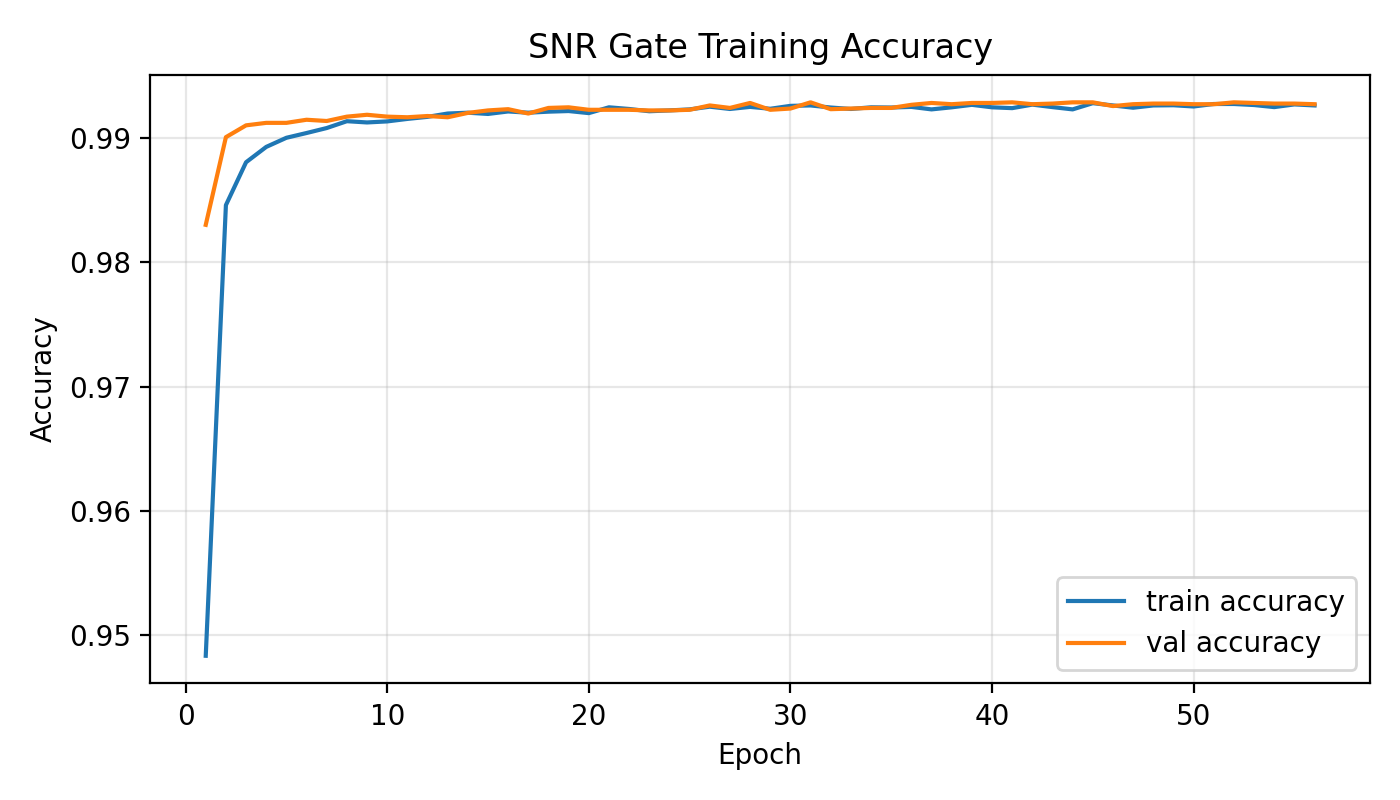

experiments/snr_gate_lightweight/logs/snr_gate_loss.png


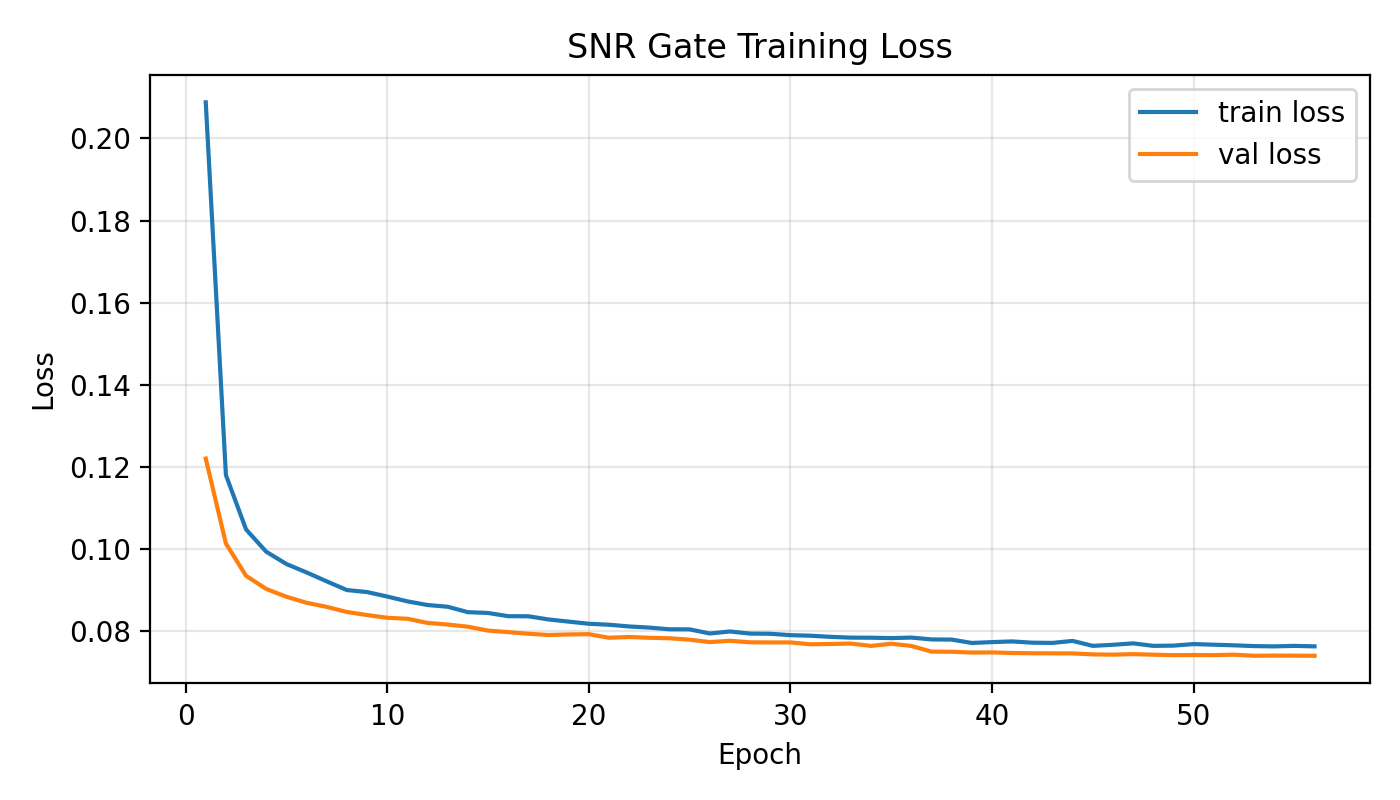

experiments/snr_gate_lightweight/figures/snr_gate_accuracy_vs_snr.png


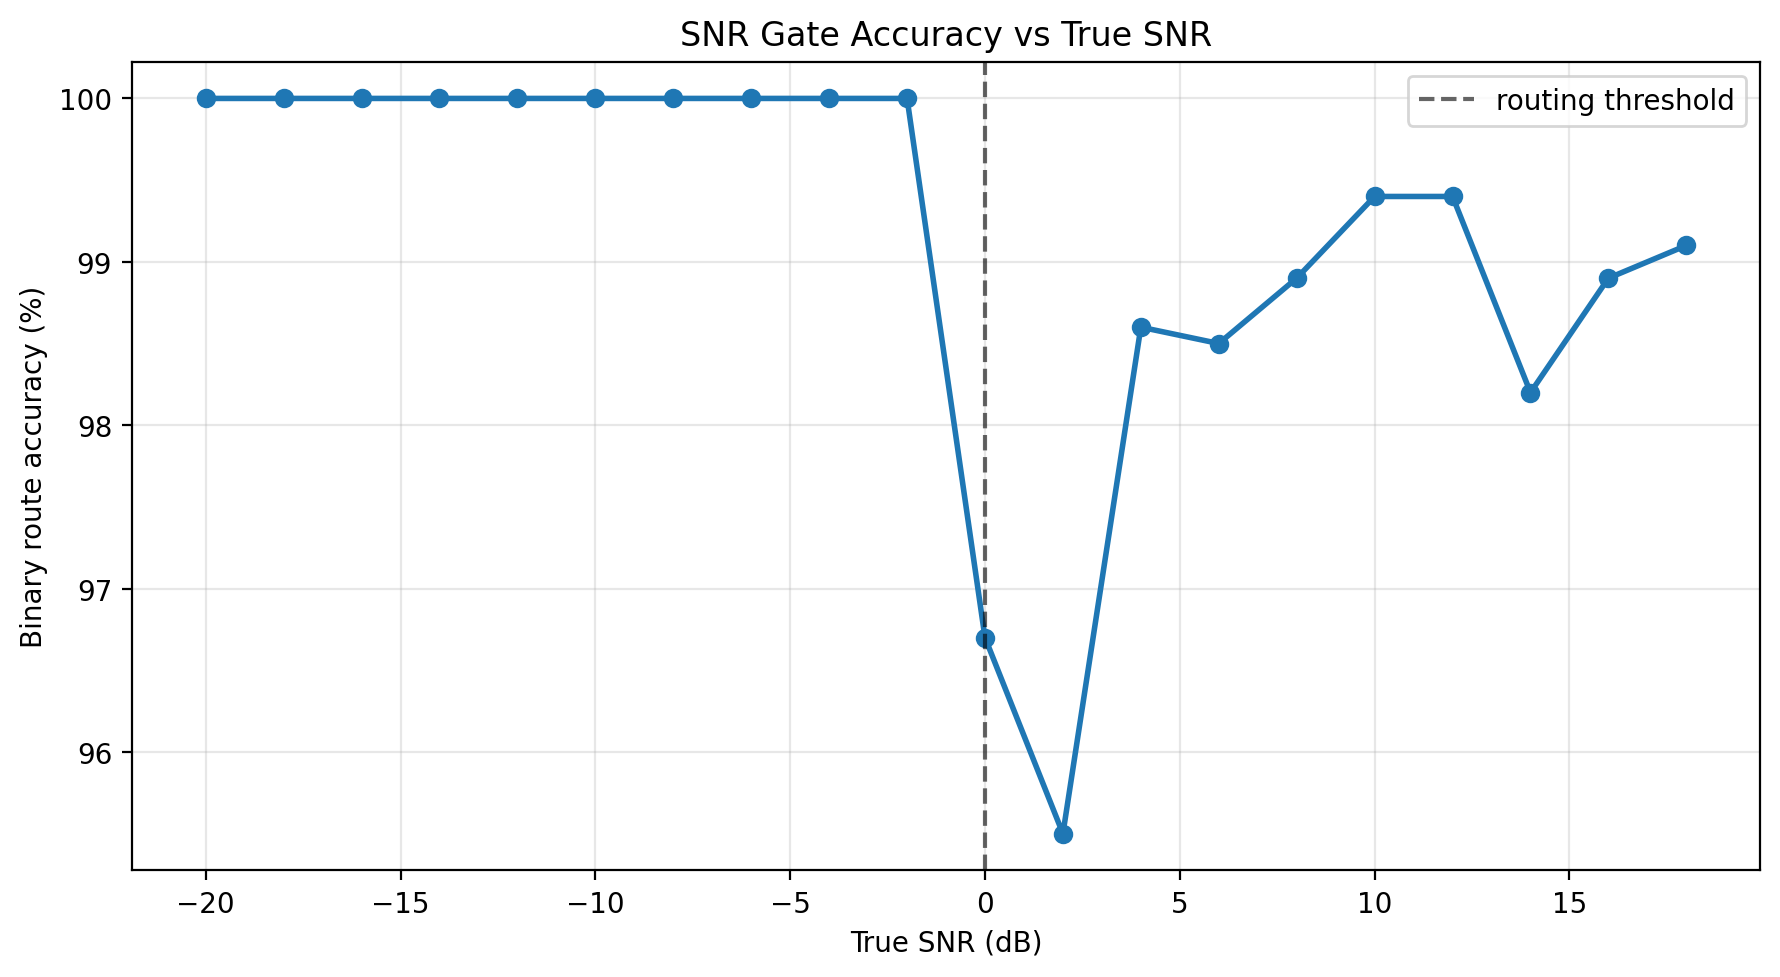

experiments/snr_gate_lightweight/figures/snr_gate_p_low_vs_snr.png


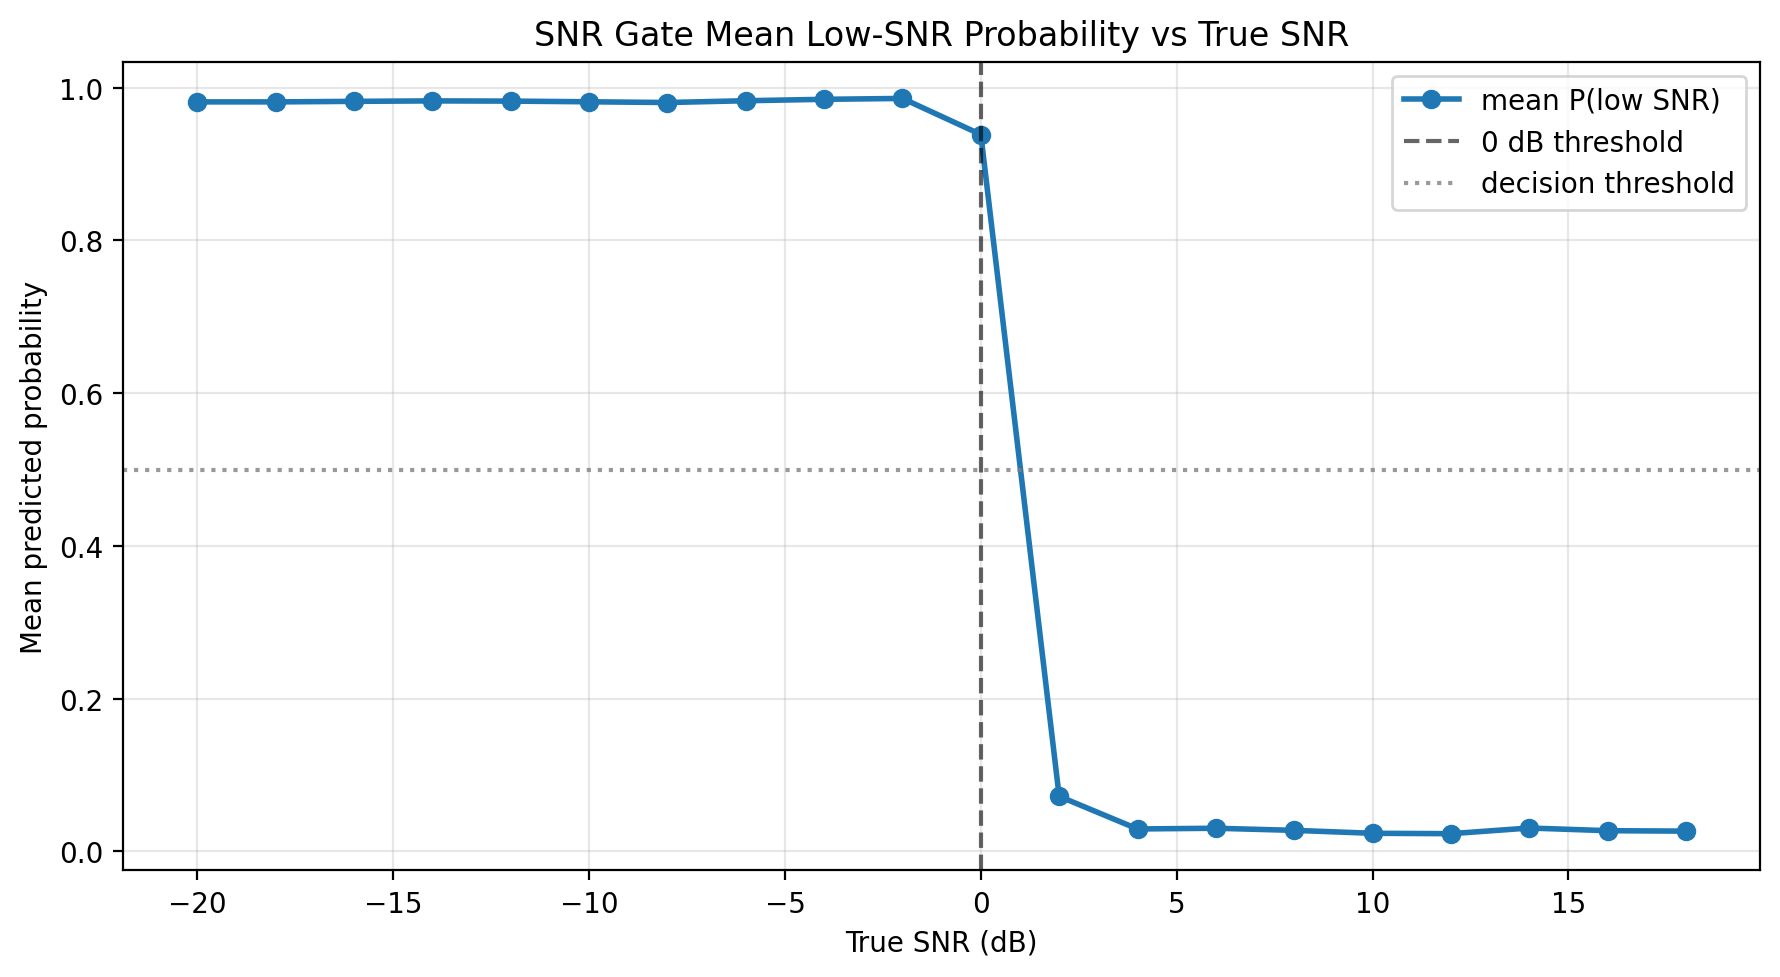

experiments/snr_gate_lightweight/figures/snr_gate_confusion.png


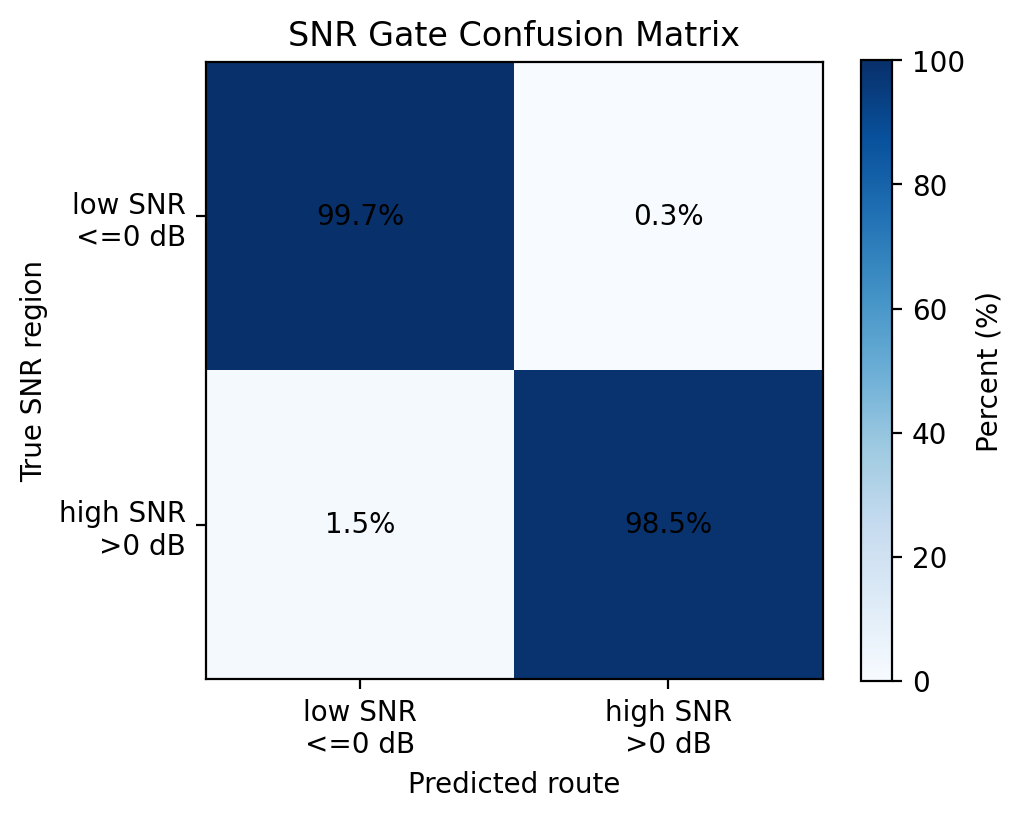

In [8]:
# CELL 6: Display figures
from IPython.display import Image, display

figs = [
    OUT_DIR / 'logs/snr_gate_accuracy.png',
    OUT_DIR / 'logs/snr_gate_loss.png',
    OUT_DIR / 'figures/snr_gate_accuracy_vs_snr.png',
    OUT_DIR / 'figures/snr_gate_p_low_vs_snr.png',
    OUT_DIR / 'figures/snr_gate_confusion.png',
]

for fig in figs:
    print(fig)
    display(Image(filename=str(fig)))

In [9]:
# CELL 7: How to use this model as the automatic hybrid router
import json
import numpy as np
from src.models.snr_gate import build_snr_gate
from src.features.signal_features import extract_snr_gate_features

metadata = json.loads((OUT_DIR / 'results/snr_gate_metadata.json').read_text())
scaler = np.load(OUT_DIR / 'results/snr_gate_feature_scaler.npz')
gate = build_snr_gate(input_dim=metadata['feature_dim'])
gate.load_weights(OUT_DIR / 'checkpoints/best_model.weights.h5')

def predict_attention_route(X_iq):
    '''
    X_iq shape: (N, 2, 128), already using the same normalization as training.
    Returns route labels and probabilities.
    route 0 = differential attention, route 1 = normal attention.
    '''
    F, _ = extract_snr_gate_features(X_iq)
    F = (F - scaler['mean']) / scaler['std']
    prob = gate.predict(F.astype('float32'), verbose=0)
    route = np.argmax(prob, axis=1)
    return route, prob

print(metadata['class_mapping'])
print('Router ready: route 0 -> diff attention, route 1 -> normal attention')

{'0': 'low_snr <= 0 dB -> differential attention', '1': 'high_snr > 0 dB -> normal attention'}
Router ready: route 0 -> diff attention, route 1 -> normal attention


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [10]:
# CELL 8: Zip results for repo upload
from datetime import datetime

stamp = datetime.now().strftime('%Y%m%d_%H%M')
zip_base = Path('/kaggle/working') / f'snr_gate_lightweight_results_{stamp}'
zip_path = shutil.make_archive(str(zip_base), 'zip', root_dir='experiments', base_dir='snr_gate_lightweight')
print('Created zip:', zip_path)
print('Contains repo-ready folder: experiments/snr_gate_lightweight/')

Created zip: /kaggle/working/snr_gate_lightweight_results_20260704_1822.zip
Contains repo-ready folder: experiments/snr_gate_lightweight/
